# ESPRIT and Gridless Estimation

*Estimation of Signal Parameters via Rotational Invariance Techniques* (ESPRIT) was developed as a high-resolution Direction of Arrival (DoA) estimation. All algorithms we learned so far suffer from one massive headache: the "off-target scenario". DAS, MVDR, and MUSIC all make us scan through every possible angle to find the peaks, which is; 

1. computationally expensive, and
2. inefficient for determining targets outside the search grid.

ESPRIT completely bypasses the grid search by finding the angles directly through matrix eigenvalues, therefore providing both faster and more accurate (literally direct) target arrival angle estimation.

In [1]:
# Importing modules
import numpy as np; 
import matplotlib.pyplot as plt; 

In [ ]:
# Defining methods
hermitian = lambda array: np.conj(array).T; 


def steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelen: float) -> np.ndarray:
  iota = np.array([[np.sin(ang_elev)*np.cos(ang_azim)],
                    [np.sin(ang_elev)*np.sin(ang_azim)],
                    [np.cos(ang_elev)]]);
  return np.exp(1j*2*np.pi/wavelen*sensor_pos.T@iota); 


def d_steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelen: float) -> np.ndarray:
  a = steering_vector(sensor_pos, ang_elev, ang_azim, wavelen);
  d_omega = np.array([[np.cos(ang_elev)*np.cos(ang_azim)],
                      [np.cos(ang_elev)*np.sin(ang_azim)],
                      [-np.sin(ang_elev)]]);
  return -1j*2*np.pi/wavelen * a * sensor_pos.T@d_omega; 


def generate_pos_1d_ula(N: int, d: float, axis=(1.,0.,0.), x_init=(0.,0.,0.)) -> np.ndarray:
  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3."""); 
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis); 
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 


def calculate_crb(sensor_pos: np.ndarray, N: int, T: int, wl: float, angs_elev: np.ndarray, snr_db: float, S_db: list) -> np.ndarray:
  noise_pow = 10**(-snr_db/10); 
  sig_pow = [10**(s_db)/10 for s_db in S_db]; 
  R_ss = np.diag(np.array(sig_pow)); 

  K = angs_elev.shape[0]; 

  # Steering matrix (A_mat) Derivative matrix (D_mat) of steering vectors w.r.t angles (in degrees)
  A_mat = np.zeros((N, K), dtype=complex); 
  D_mat = np.zeros((N, K), dtype=complex); 

  for i, theta in enumerate(angs_elev):
    A_mat[:,i] = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0]; 
    D_mat[:,i] = d_steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0]; 

  Rxx_true = A_mat@R_ss@A_mat.conj().T + noise_pow*np.eye(N); 
  Rxx_inv = np.linalg.inv(Rxx_true); 

  P_A_perp = np.eye(N) - A_mat@np.linalg.inv(A_mat.conj().T@A_mat)@A_mat.conj().T; # Projection matrix onto the noise subspace

  # The Fisher Information Matrix components
  term1 = D_mat.conj().T @ P_A_perp @ D_mat; 
  term2 = (R_ss @ A_mat.conj().T @ Rxx_inv @ A_mat @ R_ss).T; 

  FIM = (2*T/noise_pow) * np.real(term1*term2); 

  return np.linalg.inv(FIM); 


def generate_random_targets(ang_min: float, ang_max: float, ang_dist: float, K: int) -> np.ndarray:
  while True:
    angs = np.random.uniform(ang_min, ang_max, K); 
    angs_sort = np.sort(angs); 
    for i in range(K-1):  # break for if is not valid
      is_valid = np.abs(angs_sort[i+1] - angs_sort[i]) >= ang_dist; 
      if not is_valid:
        break; 
    if is_valid: break;   # break while if is valid
  return angs; 

## Benchmark Methods: DAS, MVDR, MUSIC

Now, we have three methods we discussed earlier; namely DAS, MVDR, and MUSIC. All these methods will be used for comparison with ESPRIT, but the grid search approach that we employ for these methods will be an issue. In the coming code, we will visualize the power spectrum for the grid-search methods. However, we will also start to be interested in using more quantitative metrics.

The code block below nicely wraps the implementations of the previous three algorithms in their respective methods.

In [3]:
# Benchmark methods
def doa_est_bartlett(theta_scan: np.ndarray, sensor_pos: np.ndarray, R_xx: np.ndarray, wl: float) -> np.ndarray:
  P_bartlett = np.zeros(len(theta_scan), dtype=np.complex128); 

  for i, theta in enumerate(theta_scan):
    bartlett = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    P_bartlett[i] = np.squeeze(hermitian(bartlett) @ R_xx @ bartlett); 

  return P_bartlett; 


def doa_est_capon(theta_scan: np.ndarray, sensor_pos: np.ndarray, R_xx: np.ndarray, wl: float) -> np.ndarray:
  Rxx_inv = np.linalg.inv(R_xx); 
  P_capon = np.zeros(len(theta_scan), dtype=np.complex128); 

  for i, theta in enumerate(theta_scan):
    bartlett = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    capon = (Rxx_inv @ bartlett) / (hermitian(bartlett) @ Rxx_inv @ bartlett); 
    P_capon[i] = np.squeeze(hermitian(capon) @ R_xx @ capon); 

  return P_capon; 


def doa_est_music(theta_scan: np.ndarray, sensor_pos:  np.ndarray, R_xx: np.ndarray, wl: float, K: int):
  _, e_vec = np.linalg.eigh(R_xx); 
  Un = e_vec[:, :-K]; 

  P_music = np.zeros(len(theta_scan), dtype=np.float64); 

  for i, theta in enumerate(theta_scan):
      a_theta = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
      denominator = np.abs(a_theta.conj().T @ Un @ Un.conj().T @ a_theta); 
      P_music[i] = 1 / np.squeeze(denominator); 

  return P_music; 

## Parameters
Physical parameters:

* $c$: Speed of light. In this example, assumed to be rounded to $30*10^8\text{ m/s}$.
* $f$: Frequency of the target signals in Herz. For this example, we will use $5\text{ GHz}$
* $\lambda$: Wavelength of the target signals in meters. It is calculated by the classical formula: $\lambda = \frac{c}{f}$, which gives $6\text{ cm}$ in our case.

ULA parameters:

* $N$: # of antenna elements. We can choose this value as $16$.
* $T$: # of snapshots. Just like MUSIC, ESPRIT is also dependent on the high-accuracy estimation of the sample covariance. Therefore, we will keep the snapshot number same as the previous notebook; $4000$. 
* $K$: # of targets. For an easy case, let's keep the number of targets at $3$.

In [4]:
# Defining parameters
c = 3*1e8;      # The speed of light in vacuum (m/s)
f_c = 5*1e9;    # Target carrier frequency (Hz)
f_s = 100*1e9;  # Receiver sampling frequency (Hz)
wl = c/f_c;       # Signal wavelenght (m)
d = wl/2;       # Antenna distance (m)

N = 16;         # Number of antennas
T = 1000;       # Number of snapshots
K = 3;          # Number of targets

S_db = [0]*K;   # Target signal power (dB)
snr_db = 10.0;  # Signal-to-Noise Ratio (dB)

ang_azim = 0;   # Azimuth angle (deg)
ang_min = -60;  # Minimum elevation angle (deg)
ang_max = 60;   # Maximum elevation angle (deg)
ang_dist = 5;   # Minimum distance between targets (deg)
ang_res = 0.1   # Angular resolution in scanning (deg)

sensor_pos = generate_pos_1d_ula(N, d);                                 # Sensor position
theta_scan = np.arange(-90,90+ang_res,ang_res);                         # Angle scan
true_angles = generate_random_targets(ang_min, ang_max, ang_dist, K);   # Target elevation angles

for k in range(K):
  print(f"Target {k} True Angle: {true_angles[k]:.3f}°"); 

Target 0 True Angle: -44.524°
Target 1 True Angle: -58.875°
Target 2 True Angle: -18.533°


## Signal Generation
We will start with our traditional the narrowband far-field model with Rayleigh fading.

In [5]:
A = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in true_angles]); # Array Steering Matrix

# Data Generation
S_amp = np.diag([np.sqrt(10**(s_db / 10)) for s_db in S_db]); 
S = S_amp @ (np.random.randn(K, T) + 1j*np.random.randn(K, T))/np.sqrt(2); # Target Signals: Uncorrelated Gaussian (variance = 1.0)

# Noise: Spatially white complex Gaussian noise
noise_pow = 10**(-snr_db/10); 
Noise = np.sqrt(noise_pow) * (np.random.randn(N, T) + 1j*np.random.randn(N, T))/np.sqrt(2); 

# Received Signal at the Array
X = A @ S + Noise; 

## ESPRIT Algorithm

ESPRIT relies entirely on a specific hardware setup: *translational invariance*. Instead of looking at the antenna array as a single entity, ESPRIT divides it into two identical subarrays (**Subarray 1** and **Subarray 2**) that are exact clones of each other, shifted by a known displacement distance, $r$

Because Subarray 2 is just a shifted version of Subarray 1, any signal hitting Subarray 2 will look exactly like the signal received by Subarray 1, just delayed by a specific phase shift. This phase shift ($\phi$) is directly tied to the angle of arrival ($\theta$). If we can find this phase shift matrix, we can instantly calculate the angles.

$$\phi = \frac{2\pi d}{\lambda} \sin(\theta)$$

### Derivation
We begin by calculating the spatial covariance matrix, $\mathbf{R}_{xx}$. Of course, technically not the actual one but the estimated sample covariance $\hat{\mathbf{R}}_{xx}$, but from now on we will treat it as the true covariance matrix $\mathbf{R}_{xx}$ unless indicated otherwise. 

Next, we perform EVD, or *Singular Value Decomposition* (SVD), on $\mathbf{R}_{xx}$ to separate the data into its *signal subspace* ($\mathbf{U}_{s}$) and the *noise subspace* ($\mathbf{U}_{n}$).

$$\mathbf{R}_{xx} = \mathbf{U}_{s} \Lambda_{s} \mathbf{U}_{s}^H + \mathbf{U}_{n} \Lambda_{n} \mathbf{U}_{n}^H$$

While MUSIC throws away the signal subspace to look at the noise, ESPRIT goes the opposite way and focuses on $\mathbf{U}_{s}$. 

Then, we split the signal subspace $\mathbf{U}_{s}$ into two corresponding parts, $\mathbf{U}_{1}$ and $\mathbf{U}_{2}$ (representing Subarray 1 and Subarray 2). Because of the physical shift between the subarrays, a mathematical relationship exists between $\mathbf{U}_{1}$ and $\mathbf{U}_{2}$, defined by the rotation matrix $\mathbf{\Psi}$.

$$\mathbf{U}_{2} = \mathbf{U}_{1} \mathbf{\Psi}$$

To find $ \mathbf{\Psi}$, we solve this overdetermined system using *Total Least Squares* (TLS). 

### Total Least Squares
The reason for using TLS is that the standard Least Squares (LS) is biased because of a fundamental assumption that our independent variable ($\mathbf{U}_{1}$) is 100% perfect, and all the noise lives in our dependent variable ($\mathbf{U}_{2}$). However, because of the way we created our subarray subspaces, which is by slicing them out of the estimated signal subspace $\mathbf{U}_{s}$, both $\mathbf{U}_{1}$ and $\mathbf{U}_{2}$ contain noise.

The LS solution of $\mathbf{\Psi}$ is the simple rearrangement of the two subarray subspaces.

$$\mathbf{\Psi}_\text{LS} = (U_1^H U_1)^{-1} U_1^H U_2$$

In TLS, We want to solve $\mathbf{U}_{2} \approx \mathbf{U}_{1}\mathbf{\Psi}$. We introduce error matrices $\mathbf{E}_{1}$ and $\mathbf{E}_{2}$ for representing the noise.

$$
\begin{aligned}
(\mathbf{U}_{1} + \mathbf{E}_{1})\mathbf{\Psi} &= \mathbf{U}_{2} +\mathbf{E}_{2}
\\
(\mathbf{U}_{1} + \mathbf{E}_{1})\mathbf{\Psi} - (\mathbf{U}_{2} +\mathbf{E}_{2}) &= 0
\\
\begin{bmatrix} \mathbf{U}_{1} + \mathbf{E}_{1} & \mathbf{U}_{2} + \mathbf{E}_{2} \end{bmatrix} \begin{bmatrix} \Psi \\ -I \end{bmatrix} &= 0
\\
\left( \begin{bmatrix} \mathbf{U}_{1} & \mathbf{U}_{2} \end{bmatrix} + \begin{bmatrix} \mathbf{E}_{1} & \mathbf{E}_{2} \end{bmatrix} \right) \begin{bmatrix} \mathbf{\Psi} \\ -I \end{bmatrix} &= 0
\end{aligned}
$$

Our goal is to find a $\mathbf{\Psi}$ that minimizes the total energy of the errors $[E_1 \mid E_2]$. In order to manage that, we will use SVD. We horizontally concatenate $\mathbf{U}_{1}$ and $\mathbf{U}_{2}$ into a single giant matrix, which we will call $\mathbf{U}_{12}$

$$\mathbf{U}_{12} = \begin{bmatrix} \mathbf{U}_{1} & \mathbf{U}_{2} \end{bmatrix}$$

Since $\mathbf{U}_{1}$ and $\mathbf{U}_{2}$ are both size $m \times K$, the combined matrix $\mathbf{U}_{12}$ has the dimensions $m \times 2K$. Next, we take the SVD of this combined matrix to analyze its joint space:

$$\mathbf{U}_{12} = \mathbf{G} \mathbf{\Sigma} \mathbf{V}^H$$

Note: We use $G$ here for the left singular vectors to avoid confusing it with our original signal subspace $\mathbf{U}_{s}$. We are essentially interested in the right singular matrix $\mathbf{V}$, because the matrix $\mathbf{V}$ contains the directional information of our joint spaces. If you want to get a refresher for why that is the case, take a quick detour at the Wikipedia page for [Singular Value Decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition).

Since $\mathbf{U}_{12}$ has $2K$ columns, $\mathbf{V}$ is a square matrix of size $2K \times 2K$. We partition $\mathbf{V}$ into four equal $K \times K$ submatrices:

$$\mathbf{V} = \begin{bmatrix} \mathbf{V}_{11} & \mathbf{V}_{12} \\ \mathbf{V}_{21} & \mathbf{V}_{22} \end{bmatrix}$$

The right-hand columns ($\begin{bmatrix} \mathbf{V}_{12}& \mathbf{V}_{22} \end{bmatrix}^T$) correspond to the smallest singular values in $\mathbf{\Sigma}$. In numerical linear algebra, these columns represent the "noise" or "null" subspace of our joint matrix equation. For the TLS error condition to be minimized perfectly, the block elements of the null space must satisfy the following relation derived from our original setup. From here, we simply solve for $\mathbf{\Psi}$ by isolating it.

$$
\begin{aligned}
\mathbf{V}_{12} + \mathbf{V}_{22}\Psi &= 0
\\
V_{22}\Psi &= -\mathbf{V}_{12}
\\
\mathbf{\Psi}_{\text{TLS}} &= -\mathbf{V}_{12} \mathbf{V}_{22}^{-1}
\end{aligned}
$$

Once we have computed $\mathbf{\Psi}_{\text{TLS}}$, we calculate its eigenvalues ($\nu_k$), extract the phase angles $\phi_k = \angle \nu_k$, and finally map those phases back to your physical spatial angles.

$$\theta_{k} = \arcsin\left(\frac{\lambda \phi_{k}}{2\pi r}\right)$$

By using TLS, even if the data snapshots are highly corrupted by ambient noise, the orthogonal minimization prevents the target angle estimates from drifting or biasing inward, making ESPRIT incredibly precise.


In [6]:
# The ESPRIT algorithm
R_xx = (X @ X.conj().T)/T;      # Sample covariance matrix
U, _, _ = np.linalg.svd(R_xx);  # Left singular matrix
#_, U = np.linalg.eigh(R_xx); 
Us = U[:, :K];                  # Signal Subspace

# Maximally overlapping subarrays 
U1 = Us[:-1, :];                # First M-1 rows (Subarray 1)
U2 = Us[1:, :];                 # Last M-1 rows (Subarray 2)

# Total Least Squares (TLS) to find Rotation Matrix (Psi)
U12 = np.hstack((U1, U2)); 

_, _, Vh_tls = np.linalg.svd(U12); 
V_tls = Vh_tls.T.conj();        # Get right singular vectors as columns

# Partition the V matrix to isolate the null space (right half of V)
V12 = V_tls[:K, K:];            # Top-right K x K block
V22 = V_tls[K:, K:];            # Bottom-right K x K block

Psi_tls = -V12 @ np.linalg.inv(V22);        # The TLS rotation matrix

eigenvalues = np.linalg.eigvals(Psi_tls);   # Complex eigenvalues of the rotation matrix
phases = np.angle(eigenvalues);             # The phases (angles) of the eigenvalues

# Back-calculate the spatial angles of arrival (in radians, then to degrees)
estimated_angles_rad = np.arcsin(phases / (2 * np.pi * (d / wl))); 
estimated_angles_deg = np.sort(np.rad2deg(estimated_angles_rad)); 

In [7]:
# Printing Results
true_angles_sorted = true_angles[np.argsort(true_angles)]; 
S_db_sorted = np.array(S_db)[np.argsort(true_angles)]; 

## Cramer-Rao Bound
CRB_mat = calculate_crb(sensor_pos, N, T, wl, true_angles_sorted, snr_db, S_db_sorted); 
CRB_var = np.diag(CRB_mat);       # The diagonal elements are the minimum variances for target 1 and target 2
CRB_rmse = np.sqrt(CRB_var);      # Convert variance (deg^2) to Standard Deviation / RMSE (deg)

print(f"--- DoA Estimation with the ESPRIT Algorithm ---"); 
print(f"Array Size:        {N} elements"); 
print(f"Snapshots:         {T}"); 
print(f"Target No.:        {K}"); 
print(f"SNR:               {snr_db} dB\n"); 

print("Target | True Angle (deg) | Est. Angle (deg) | Error (deg) | CRLB (deg) |"); 
print("-" * 72);
for k in range(K):
    error = np.abs(true_angles_sorted[k] - estimated_angles_deg[k]); 
    print(f"  {k+1}    | {true_angles_sorted[k]:>16.4f} | {estimated_angles_deg[k]:>16.4f} | {error:>11.4f} | {CRB_rmse[k]:>10.4f} |"); 

--- DoA Estimation with the ESPRIT Algorithm ---
Array Size:        16 elements
Snapshots:         1000
Target No.:        3
SNR:               10.0 dB

Target | True Angle (deg) | Est. Angle (deg) | Error (deg) | CRLB (deg) |
------------------------------------------------------------------------
  1    |         -58.8748 |         -58.8856 |      0.0108 |     0.0008 |
  2    |         -44.5237 |         -44.5184 |      0.0053 |     0.0006 |
  3    |         -18.5325 |         -18.5350 |      0.0025 |     0.0004 |


In [8]:
# Running the compared algorithms (DAS, MVDR, and MUSIC)
Rxx_samp = (X @ X.conj().T)/T; 

P_bartlett = doa_est_bartlett(theta_scan, sensor_pos, Rxx_samp, wl); 
P_bartlett_dB = 10*np.log10(np.abs(np.multiply(P_bartlett/np.amax(P_bartlett), np.conjugate(P_bartlett/np.amax(P_bartlett))))); 

P_capon = doa_est_capon(theta_scan, sensor_pos, Rxx_samp, wl); 
P_capon_dB = 10*np.log10(np.abs(np.multiply(P_capon/np.amax(P_capon), np.conjugate(P_capon/np.amax(P_capon))))); 

P_music = doa_est_music(theta_scan, sensor_pos, Rxx_samp, wl, K); 
P_music_dB = 10 * np.log10(P_music / np.max(P_music)); 

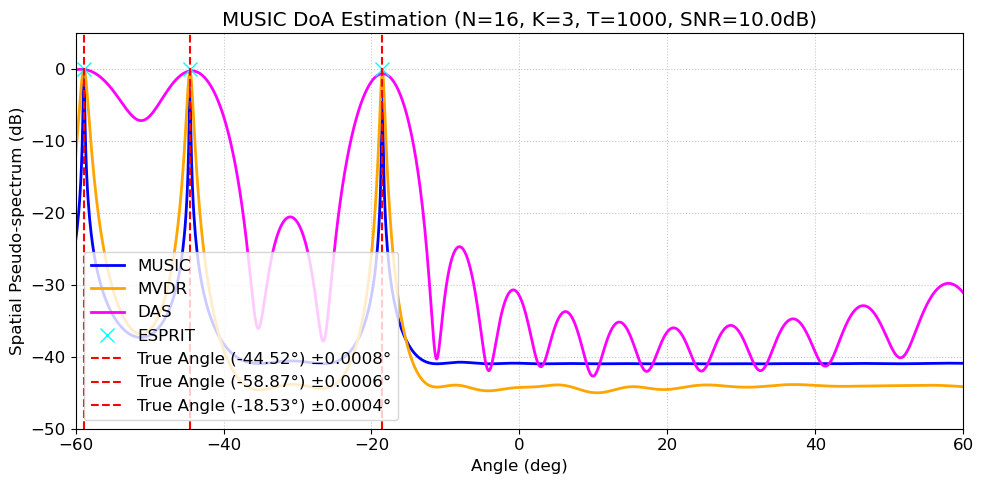

In [9]:
# Visualization
plt.rcParams.update({"font.size": 12}); 

plt.figure(figsize=(10, 5)); 
plt.plot(theta_scan, P_music_dB, linewidth=2, color="blue", label="MUSIC"); 
plt.plot(theta_scan, P_capon_dB, linewidth=2, color="orange", label="MVDR"); 
plt.plot(theta_scan, P_bartlett_dB, linewidth=2, color="magenta", label="DAS"); 

plt.plot(estimated_angles_deg, [0]*K, marker='x', markersize=10, color="cyan", ls='', label="ESPRIT"); 

for i, angle in enumerate(true_angles):
  plt.axvline(x=angle, color="red", linestyle="--", 
              label=f"True Angle ({angle:.2f}°) ±{CRB_rmse[i]:.4f}°"); 

plt.title(f"MUSIC DoA Estimation (N={N}, K={K}, T={T}, SNR={snr_db}dB)"); 
plt.xlabel("Angle (deg)"); 
plt.ylabel("Spatial Pseudo-spectrum (dB)"); 
plt.xlim([ang_min, ang_max]); 
plt.ylim([-50, 5]); 
plt.grid(True, linestyle=':', alpha=0.7); 

handles, labels = plt.gca().get_legend_handles_labels(); 
by_label = dict(zip(labels, handles)); 
plt.legend(by_label.values(), by_label.keys(), loc="lower left"); 

plt.tight_layout(); 
plt.show(); 

ESPRIT works like a charm! And we managed to do so without having to scan over a whole range of angles.

## ESPRIT with Alternative Target Scenarios

In [10]:
# Wrapping ESPRIT into its own method
def doa_est_esprit(R_xx: np.ndarray, d: float, wl: float, K: int) -> np.ndarray:
  """
  Calculates ESPRIT from the maximal subarray to find K target arrival angles in degrees.

  --Inputs--
  R_xx: Sample covariance matrix of the received signal (N x N). Type of np.ndarray 
    of size (N,N) and dtype of np.complex128.
  d: Inter-element spacing of the array in meters. Type of float.
  wl: Narrowband carrier wavelength in meters. Type of float.
  K: Number of targets. Type of int.

  --Output--
  Estimated K-number of arrival angles in degrees. Type of np.ndarray of size (K,) 
    and dtype of np.float64.
  """
  U, _, _ = np.linalg.svd(R_xx);      # Left singular matrix
  Us = U[:, :K];                      # Signal Subspace

  U1 = Us[:-1, :];                    # First M-1 rows (Subarray 1)
  U2 = Us[1:, :];                     # Last M-1 rows (Subarray 2)
  U12 = np.hstack((U1, U2)); 

  _, _, Vh = np.linalg.svd(U12); 
  Vh = Vh.T.conj(); 
  V12 = Vh[:K, K:]; 
  V22 = Vh[K:, K:]; 

  Psi = -V12 @ np.linalg.inv(V22); 

  eig_vals = np.linalg.eigvals(Psi);   # Complex eigenvalues of the rotation matrix
  phases = np.angle(eig_vals);         # The phases (angles) of the eigenvalues

  estimated_angles_rad = np.arcsin(phases / (2 * np.pi * (d / wl))); 
  return np.sort(np.rad2deg(estimated_angles_rad)); # returns in degrees

### ESPRIT with Low Snapshot

In [11]:
X_l = X[:,:100];                        # Low-snapshot signal
Rxx_samp_l = (X_l @ hermitian(X_l))/T;  # The low-snapshot sample covariance matrix

estimated_angles_deg_l = doa_est_esprit(Rxx_samp_l, d, wl, K); 

print(f"--- DoA Estimation with the ESPRIT Algorithm ---"); 
print(f"Array Size:        {N} elements"); 
print(f"Snapshots:         {T}"); 
print(f"Target No.:        {K}"); 
print(f"SNR:               {snr_db} dB\n"); 

print("Target | True Angle (deg) | Est. Angle (deg) | Error (deg) | CRLB (deg) |"); 
print("-" * 72); 
for k in range(K):
    error = np.abs(true_angles_sorted[k] - estimated_angles_deg_l[k]); 
    print(f"  {k+1}    | {true_angles_sorted[k]:>16.4f} | {estimated_angles_deg_l[k]:>16.4f} | {error:>11.4f} | {CRB_rmse[k]:>10.4f} |"); 

--- DoA Estimation with the ESPRIT Algorithm ---
Array Size:        16 elements
Snapshots:         1000
Target No.:        3
SNR:               10.0 dB

Target | True Angle (deg) | Est. Angle (deg) | Error (deg) | CRLB (deg) |
------------------------------------------------------------------------
  1    |         -58.8748 |         -58.8793 |      0.0045 |     0.0008 |
  2    |         -44.5237 |         -44.4533 |      0.0704 |     0.0006 |
  3    |         -18.5325 |         -18.5223 |      0.0102 |     0.0004 |


### ESPRIT with Correlated Targets

In [ ]:
# Rician Fading Target Generation
K_factor_db = 10; 
K_factor_lin = 10**(K_factor_db/10); 

los_amp = np.sqrt(K_factor_lin/(K_factor_lin + 1)); 
nlos_amp = np.sqrt(1 / (K_factor_lin + 1)); 

phase = np.random.uniform(0, 2*np.pi, size=(K));    # Assuming random phase
S_los = np.column_stack([np.exp(1j*2*np.pi*f_c * np.arange(0,(T-1)/f_s,1/f_s)) * np.exp(1j * phase[k]) for k in range(K)]).T; 
S_nlos = (np.random.randn(K, T) + 1j * np.random.randn(K, T)) / np.sqrt(2); 
S_rician = los_amp * S_los + nlos_amp * S_nlos; 

Sr = S_amp @ S_rician;                              # Final target matrix

Hr = np.sqrt(noise_pow) * (np.random.randn(N,T) + 1j*np.random.randn(N,T))/np.sqrt(2); 

Xr = A @ Sr + Hr; 



In [13]:
Rxx_samp_rc = (Xr @ hermitian(Xr))/T;                               # The low-snapshot sample covariance matrix

estimated_angles_deg_rc = doa_est_esprit(Rxx_samp_rc, d, wl, K); 

print(f"--- DoA Estimation with the ESPRIT Algorithm ---"); 
print(f"Array Size:        {N} elements"); 
print(f"Snapshots:         {T}"); 
print(f"Target No.:        {K}"); 
print(f"SNR:               {snr_db} dB\n"); 

print("Target | True Angle (deg) | Est. Angle (deg) | Error (deg) | CRLB (deg) |"); 
print("-" * 72); 
for k in range(K):
    error = np.abs(true_angles_sorted[k] - estimated_angles_deg_rc[k]); 
    print(f"  {k+1}    | {true_angles_sorted[k]:>16.4f} | {estimated_angles_deg_rc[k]:>16.4f} | {error:>11.4f} | {CRB_rmse[k]:>10.4f} |"); 

--- DoA Estimation with the ESPRIT Algorithm ---
Array Size:        16 elements
Snapshots:         1000
Target No.:        3
SNR:               10.0 dB

Target | True Angle (deg) | Est. Angle (deg) | Error (deg) | CRLB (deg) |
------------------------------------------------------------------------
  1    |         -58.8748 |         -58.7958 |      0.0790 |     0.0008 |
  2    |         -44.5237 |         -44.4107 |      0.1130 |     0.0006 |
  3    |         -18.5325 |         -18.5586 |      0.0261 |     0.0004 |


ESPRIT and MUSIC are essentially bound to the knowledge of the number of targets $K$. We will see in the next notebook on how to make sure that we have this knowledge beforehand.

## References

Paper for the ESPRIT algorithm is [here](https://ieeexplore.ieee.org/abstract/document/32276).